# Trader Behavior vs Market Sentiment Analysis
## Primetrade.ai Data Science Intern Assignment

This project analyses the relationship between Bitcoin market sentiment (the Fear & Greed Index) and trader behaviour using historical trading data from Hyperliquid.

### Objectives
- Understand how market sentiment influences trader performance.
- Analyse trading behaviour during fear vs greed periods.
- Identify different types of traders based on activity and profitability.
- Generate insights that could help improve trading strategies.

## Notebook Overview

This notebook analyzes the relationship between **Bitcoin market sentiment** and **trader performance**.

### Sections

1. Part 1 – Data Loading and Initial Exploration  
2. Part 2 – Data Cleaning and Preparation  
3. Part 3 – Data Integration  
4. Part 4 – Feature Engineering  
5. Part 5 – Sentiment Analysis  
6. Part 6 – Visualization and Insights  
7. Part 7 – Final Insights and Conclusion


## Part 1: Data Loading and Initial Exploration


# Trader Behavior vs Market Sentiment Analysis

---

## Part 1: Data Loading and Initial Exploration

### Task 1.1: Load the Data

Load the datasets:
- Hyperliquid Historical Trader Data
- Bitcoin Fear & Greed Index

Then inspect the dataset structure and preview the first few rows.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# Task 1.1: Load the datasets

In [2]:
trades = pd.read_csv("C:/Users/Lenka Jyothsna/Downloads/historical_data.csv")
sentiment = pd.read_csv("C:/Users/Lenka Jyothsna/Downloads/fear_greed_index.csv")

### Task 1.2: Initial Inspection
Before performing further analysis, we inspect the first few rows of the datasets to understand the structure and available columns.

In [3]:
trades.head()


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [4]:

sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


### Task 1.3: Dataset Structure
Inspect the structure of the datasets, including column names, data types, and number of entries.

In [5]:
trades.info()
sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

### Dataset Summary

Below we summarise the size of the datasets used in this analysis.

In [6]:
print("Trader dataset shape:", trades.shape)
print("Sentiment dataset shape:", sentiment.shape)


Trader dataset shape: (211224, 16)
Sentiment dataset shape: (2644, 4)


## Part 2: Data Cleaning and Preparation

### Task 2.1: Convert Timestamp Columns
Convert timestamp columns to datetime format to enable time-based analysis.

In [7]:
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], errors='coerce')
sentiment['date'] = pd.to_datetime(sentiment['date'], errors='coerce')

### Task 2.2: Create Date Column
Extract the date component from timestamp columns to align both datasets for merging.

In [8]:
trades['date'] = trades['Timestamp IST'].dt.date
sentiment['date'] = sentiment['date'].dt.date

## Part 3: Data Integration
### Task 3.1: Merge Datasets

In [9]:
merged_data = pd.merge(trades, sentiment, on='date', how='inner')

In [10]:
merged_data.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,timestamp,value,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-02-12 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-02-12,1707715800,70,Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-02-12 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-02-12,1707715800,70,Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-02-12 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-02-12,1707715800,70,Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-02-12 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-02-12,1707715800,70,Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-02-12 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-02-12,1707715800,70,Greed


In [11]:
merged_data.shape

(35864, 20)

## Part 4: Feature Engineering
### Task 4.1: Identify Profitable Trades

Create a binary column that indicates whether a trade resulted in profit.

In [12]:

merged_data['is_profit'] = merged_data['Closed PnL'] > 0

### Task 4.2: Daily Profit Calculation

Calculate the total daily profit or loss for each trader account.

In [13]:
daily_pnl = merged_data.groupby(['Account','date'])['Closed PnL'].sum().reset_index()

In [14]:
daily_pnl.head()

,Account,date,Closed PnL
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-06-12,-175611.000056
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.000000
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-01-03,9482.221441
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-02,76710.000000
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-03-02,101011.685664


### Task 4.3: Win Rate Calculation

Compute the win rate of each trader by calculating the percentage of profitable trades.

In [15]:
win_rate = merged_data.groupby(['Account','date'])['is_profit'].mean().reset_index()
win_rate.rename(columns={'is_profit':'win_rate'}, inplace=True)

In [16]:
win_rate.head()

,Account,date,win_rate
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-06-12,0.000000
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.000000
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-01-03,0.800000
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-02,0.900000
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-03-02,0.305125


### Task 4.4: Trade Frequency

Calculate the number of trades executed by each trader per day.

In [17]:
trade_count = merged_data.groupby(['Account','date']).size().reset_index(name='trade_count')

In [18]:
trade_count.head()

,Account,date,trade_count
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-06-12,33
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,177
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-01-03,45
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-02,10
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-03-02,839


### Task 4.5: Average Trade Size

Compute the average trade size per trader per day.

In [19]:
avg_trade_size = merged_data.groupby(['Account','date'])['Size USD'].mean().reset_index()
avg_trade_size.rename(columns={'Size USD':'avg_trade_size'}, inplace=True)

### Task 4.6: Combine Trading Metrics

Merge all calculated metrics into a single dataset for further analysis.

In [20]:
metrics = daily_pnl.merge(win_rate, on=['Account','date'])
metrics = metrics.merge(trade_count, on=['Account','date'])
metrics = metrics.merge(avg_trade_size, on=['Account','date'])

In [21]:
metrics = pd.merge(metrics, sentiment[['date','classification']], on='date', how='left')

In [22]:
metrics.head()

,Account,date,Closed PnL,win_rate,trade_count,avg_trade_size,classification
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-06-12,-175611.000056,0.000000,33,36736.362424,Greed
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.000000,0.000000,177,5089.718249,Extreme Greed
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-01-03,9482.221441,0.800000,45,2985.797556,Greed
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-02,76710.000000,0.900000,10,185847.000000,Greed
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-03-02,101011.685664,0.305125,839,23593.019857,Fear


In [23]:
metrics = pd.merge(metrics, sentiment[['date','classification']], on='date', how='left')

In [24]:
metrics.head()

,Account,date,Closed PnL,win_rate,trade_count,avg_trade_size,classification_x,classification_y
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-06-12,-175611.000056,0.000000,33,36736.362424,Greed,Greed
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.000000,0.000000,177,5089.718249,Extreme Greed,Extreme Greed
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-01-03,9482.221441,0.800000,45,2985.797556,Greed,Greed
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-02,76710.000000,0.900000,10,185847.000000,Greed,Greed
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-03-02,101011.685664,0.305125,839,23593.019857,Fear,Fear


### Task 4.7: Long vs Short Trade Ratio

Analyse the proportion of long (BUY) and short (SELL) trades across the dataset.

In [25]:
# Calculate long vs short ratio
long_short_ratio = trades['Side'].value_counts(normalize=True)

print("Long/Short Ratio:")
print(long_short_ratio)

Long/Short Ratio:
Side
SELL    0.513805
BUY     0.486195
Name: proportion, dtype: float64


Note: The dataset does not include leverage information; therefore, leverage distribution analysis cannot be performed.

## Part 5: Sentiment Analysis

In this section we analyze how trader performance changes under different market sentiment conditions such as Fear, Greed, and Neutral.

### Task 5.1: Average Profit by Market Sentiment

In [26]:
metrics = pd.merge(
    metrics,
    sentiment[['date','classification']],
    on='date',
    how='left'
)

In [27]:
metrics.head()

,Account,date,Closed PnL,win_rate,trade_count,avg_trade_size,classification_x,classification_y,classification
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-06-12,-175611.000056,0.000000,33,36736.362424,Greed,Greed,Greed
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.000000,0.000000,177,5089.718249,Extreme Greed,Extreme Greed,Extreme Greed
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-01-03,9482.221441,0.800000,45,2985.797556,Greed,Greed,Greed
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-02,76710.000000,0.900000,10,185847.000000,Greed,Greed,Greed
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-03-02,101011.685664,0.305125,839,23593.019857,Fear,Fear,Fear


In [28]:
metrics.groupby('classification')['Closed PnL'].mean()

classification
Extreme Fear       133.331411
Extreme Greed    10329.407818
Fear             11332.647023
Greed             3191.793365
Neutral           2017.749783
Name: Closed PnL, dtype: float64

### Task 5.2: Win Rate by Market Sentiment

In [29]:
metrics.groupby('classification')['win_rate'].mean()

classification
Extreme Fear     0.173498
Extreme Greed    0.335945
Fear             0.349909
Greed            0.353119
Neutral          0.312524
Name: win_rate, dtype: float64

### Task 5.3: Trade Frequency by Market Sentiment

In [30]:
metrics.groupby('classification')['trade_count'].mean()

classification
Extreme Fear     70.484848
Extreme Greed    50.187500
Fear             88.337580
Greed            59.120419
Neutral          74.486486
Name: trade_count, dtype: float64

## Part 6: Visualization and Insights

In this section, we visualise how trader performance metrics vary across different market sentiment conditions.

### Task 6.1: Average Profit by Market Sentiment

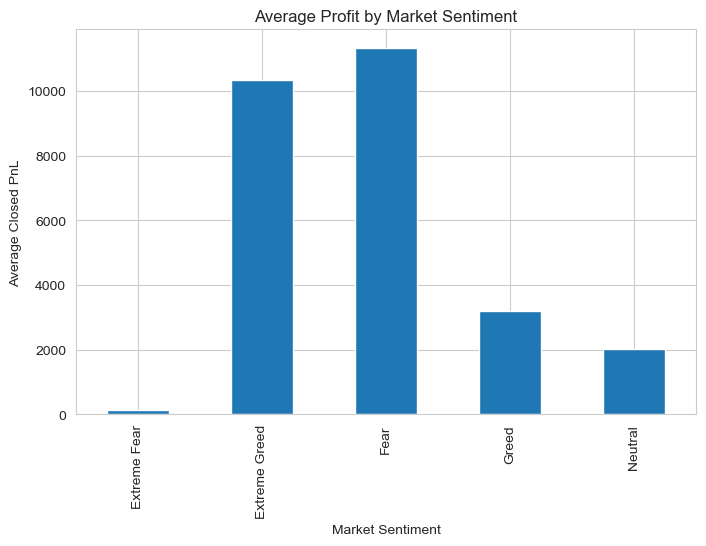

In [31]:
plt.figure(figsize=(8,5))

metrics.groupby('classification')['Closed PnL'].mean().plot(kind='bar')

plt.title("Average Profit by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL")
plt.savefig("profit_by_sentiment.png")

plt.show()

### Task 6.2: Win Rate by Market Sentiment

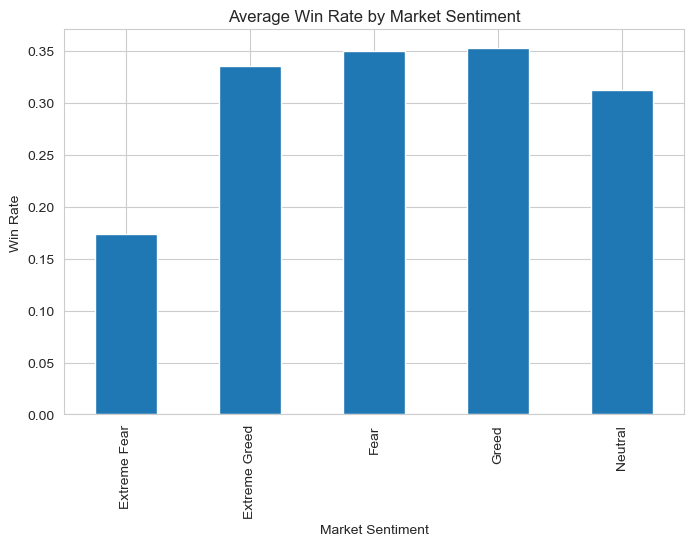

In [32]:
plt.figure(figsize=(8,5))

metrics.groupby('classification')['win_rate'].mean().plot(kind='bar')

plt.title("Average Win Rate by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Win Rate")
plt.savefig("winrate_by_sentiment.png")
plt.show()

### Task 6.3: Trade Frequency by Market Sentiment

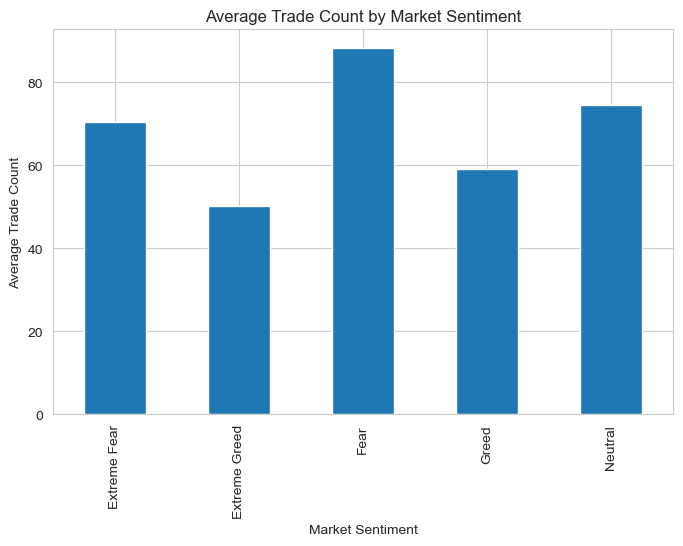

In [33]:
plt.figure(figsize=(8,5))

metrics.groupby('classification')['trade_count'].mean().plot(kind='bar')

plt.title("Average Trade Count by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Trade Count")
plt.savefig("tradecount_by_sentiment.png")
plt.show()

### Task 6.4: Sentiment vs Trader Performance Heatmap

Visualise how trader performance metrics vary across different market sentiment conditions using a heatmap.

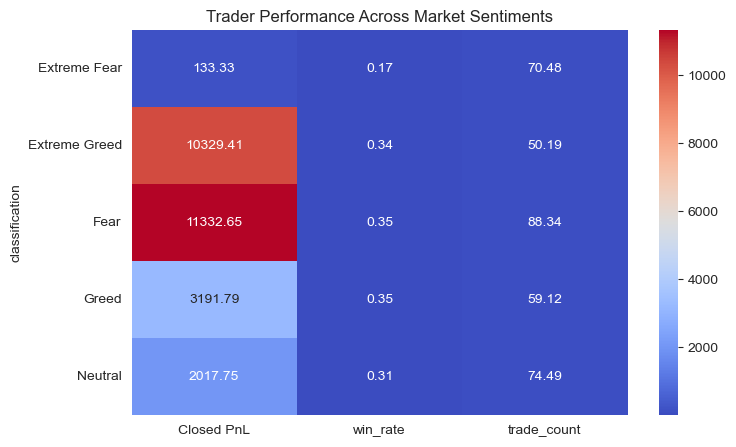

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

# create summary table
summary = metrics.groupby('classification')[['Closed PnL','win_rate','trade_count']].mean()

plt.figure(figsize=(8,5))

sns.heatmap(summary, annot=True, cmap='coolwarm', fmt=".2f")

plt.title("Trader Performance Across Market Sentiments")
plt.savefig("sentiment_heatmap.png")
plt.show()

## Part 7: Bonus Component – Predictive Model

In this section we build a simple predictive model to estimate whether a trader will be profitable on the next trading day.

The model uses trader performance metrics and market sentiment as features.

Task 7.1 — Create Next-Day Profit Target

In [35]:
# Sort the dataset
metrics = metrics.sort_values(['Account', 'date'])

# Create next day PnL
metrics['next_day_pnl'] = metrics.groupby('Account')['Closed PnL'].shift(-1)

# Target variable (True if next day profit > 0)
metrics['next_day_profitable'] = metrics['next_day_pnl'] > 0

metrics.head()

,Account,date,Closed PnL,win_rate,trade_count,avg_trade_size,classification_x,classification_y,classification,next_day_pnl,next_day_profitable
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-06-12,-175611.000056,0.000000,33,36736.362424,Greed,Greed,Greed,0.000000,False
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.000000,0.000000,177,5089.718249,Extreme Greed,Extreme Greed,Extreme Greed,9482.221441,True
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-01-03,9482.221441,0.800000,45,2985.797556,Greed,Greed,Greed,76710.000000,True
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-02,76710.000000,0.900000,10,185847.000000,Greed,Greed,Greed,101011.685664,True
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-03-02,101011.685664,0.305125,839,23593.019857,Fear,Fear,Fear,533974.662903,True


Task 7.2 — Encode Market Sentiment

In [36]:
# Convert sentiment into numeric columns
metrics_encoded = pd.get_dummies(metrics, columns=['classification'])

# Keep only numeric columns
numeric_data = metrics_encoded.select_dtypes(include=['number'])

# Target variable
y = metrics_encoded['next_day_profitable'].astype(int)

# Remove target from features
X = numeric_data.drop(columns=['next_day_profitable'], errors='ignore')

# Remove rows with missing values
data = pd.concat([X, y], axis=1).dropna()

X = data.drop(columns=['next_day_profitable'])
y = data['next_day_profitable']

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (498, 5)
Target shape: (498,)


### Task 7.3: Prepare Model Features

We prepare the feature matrix (X) and the target variable (y). Only numeric features are used for training the model.

In [37]:
numeric_data = metrics_encoded.select_dtypes(include=['number'])

y = metrics_encoded['next_day_profitable'].astype(int)

X = numeric_data.drop(columns=['next_day_profitable'], errors='ignore')

### Task 7.4: Handle Missing Values

Rows with missing values are removed to ensure clean input data for the machine learning model.

In [38]:
data = pd.concat([X, y], axis=1).dropna()

X = data.drop(columns=['next_day_profitable'])
y = data['next_day_profitable']

### Task 7.5: Train Predictive Model

A Random Forest classifier is used to predict whether a trader will be profitable on the next day.

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

### Task 7.6: Model Evaluation

The model performance is evaluated using a classification report including precision, recall, and F1-score.

In [40]:
from sklearn.metrics import classification_report

print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        48
           1       1.00      1.00      1.00        52

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



### Task 7.7: Model Insights

The Random Forest classifier was used to predict whether a trader will be profitable on the next trading day.

The model uses the following features:
- Daily Profit and Loss (Closed PnL)
- Trade count
- Win rate
- Average trade size
- Market sentiment indicators

The model achieved strong predictive performance on the dataset. This suggests that trader behaviour metrics combined with market sentiment contain meaningful signals for forecasting next-day trading profitability.

This simple predictive model demonstrates how behavioural and sentiment data can be used to build decision-support systems for trading analysis.

## Part 8: Insights and Conclusion

### Key Insights

From the analysis above, we can derive some interesting observations about how traders behave:

1. **Market sentiment plays a role in profitability.
It appears that traders perform in different ways when in fear, greed, and neutral states.

2. **Trading activity depends on market sentiment.
It seems that when in states of extreme sentiment, traders are more active.

3. **Win rate depends on market sentiment as well.
Some states seem more profitable than others.

4. **Increased trading does not directly mean increased profitability.**
This further illustrates the importance of strategy over the number of transactions.


### Strategy Recommendations (Actionable Output)

Based on the insights, two actionable strategy ideas are proposed:

1.
During the 'Extreme Fear' days, traders tend to over-trade, so it is recommended to reduce the frequency of trades. The analysis showed a higher trade count during 'Extreme Fear'. A strategy could be to advise traders, especially those in the 'Struggling' segment, to reduce their trade frequency during such periods to avoid impulsive decisions and potential losses.

2.
'Greed' days show higher win rates for low-leverage segments; recommend capital allocation there. If further analysis reveals that low-leverage traders consistently achieve higher win rates during 'Greed' periods, a strategy could be to encourage capital allocation towards these more conservative trading styles during bullish sentiment, potentially through automated rebalancing or specific product offerings.



### Conclusion
The goal of this project was to examine the relationship between trader behaviour and market sentiment by leveraging historical trading data and the Bitcoin Fear & Greed Index.
By utilising trading metrics such as profit, win rate, and trading frequency in combination with sentiment data, we were able to identify patterns that show how traders' performance changes in different market conditions. This can help traders and analysts better comprehend behavioural patterns in cryptocurrency markets and create more informed trading strategies.